In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


# Import Dataset

In [2]:
df = pd.read_csv(r'C:\Users\user\Desktop\case studey ass\Divvy_Trips_2020.csv')
df.head(2)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,StartDate,EndDate,Days,Time_start,Time_end,Time taken(hh:mm),Distance Cover,Distance Distribution
0,EACB19130B0CDA4A,docked_bike,1/21/2020 20:06,1/21/2020 20:14,Western Ave & Leland Ave,239,Clark St & Leland Ave,326.0,41.9665,-87.6884,...,-87.6674,member,1/21/2020,1/21/2020,0,20:06,20:14,00:08,2.33,Normal
1,8FED874C809DC021,docked_bike,1/30/2020 14:22,1/30/2020 14:26,Clark St & Montrose Ave,234,Southport Ave & Irving Park Rd,318.0,41.9616,-87.6660,...,-87.6644,member,1/30/2020,1/30/2020,0,14:22,14:26,00:04,0.84,Short


# Dataset Cloumn Detail
| Column Name             | Explanation                                                                                                                       |
| ----------------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| `ride_id`               | Unique ID assigned to each bike trip. Every ride has a different identifier.                                                      |
| `rideable_type`         | Type of bike used during the ride. Examples: `docked_bike`, `classic_bike`, `electric_bike`.                                      |
| `started_at`            | Exact date and time when the ride started.                                                                                        |
| `ended_at`              | Exact date and time when the ride ended.                                                                                          |
| `start_station_name`    | Name of the station where the bike was taken from.                                                                                |
| `start_station_id`      | Unique ID of the starting station.                                                                                                |
| `end_station_name`      | Name of the station where the bike was returned.                                                                                  |
| `end_station_id`        | Unique ID of the ending station.                                                                                                  |
| `start_lat`             | Latitude coordinate of the starting location.                                                                                     |
| `start_lng`             | Longitude coordinate of the starting location.                                                                                    |
| `end_lat`               | Latitude coordinate of the ending location.                                                                                       |
| `end_lng`               | Longitude coordinate of the ending location.                                                                                      |
| `member_casual`         | Type of customer using the bike: `member` = subscribed user, `casual` = non-member/temporary rider.                               |
| `StartDate`             | Extracted date-only value from `started_at`. Used for easier date analysis.                                                       |
| `EndDate`               | Extracted date-only value from `ended_at`.                                                                                        |
| `Days`                  | Number of days between ride start and end. Usually `0` for same-day rides.                                                        |
| `Time_start`            | Extracted starting time only (without date).                                                                                      |
| `Time_end`              | Extracted ending time only (without date).                                                                                        |
| `Distance Cover`        | Estimated trip distance, probably calculated using latitude and longitude coordinates (in km or miles depending on your formula). |
| `Distance Distribution` | Categorized distance group based on trip length. Example: `Short`, `Normal`, `Long`.                                              |


# Dataset Cleaning

# Checking Nulls

In [3]:
df.isnull().sum()

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name       0
start_station_id         0
end_station_name         1
end_station_id           1
start_lat                0
start_lng                0
end_lat                  1
end_lng                  1
member_casual            0
StartDate                0
EndDate                  0
Days                     0
Time_start               0
Time_end                 0
Time taken(hh:mm)        0
Distance Cover           0
Distance Distribution    0
dtype: int64

# checking Valid Distance

In [4]:
df['Distance Cover'].dtype

dtype('float64')

In [5]:
df['Distance Cover'] = df['Distance Cover'].astype(float)

In [6]:
df.nlargest(5, 'Distance Cover')

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,StartDate,EndDate,Days,Time_start,Time_end,Time taken(hh:mm),Distance Cover,Distance Distribution
414426,157EAA4C4A3C8D36,docked_bike,3/16/2020 11:23,3/16/2020 11:23,HQ QR,675,NaN,NaN,41.8899,-87.6803,...,NaN,casual,3/16/2020,3/16/2020,0,11:23,11:23,00:00,10786.21,Wrong entry
322208,691842BB665D276C,docked_bike,3/10/2020 6:30,3/10/2020 17:39,Jeffery Blvd & 71st St,11,Broadway & Wilson Ave,293.0,41.7666,-87.5764,...,-87.6581,casual,3/10/2020,3/10/2020,0,6:30,17:39,11:09,23.84,Longest
387373,858A96493DC2021A,docked_bike,3/25/2020 16:40,3/25/2020 18:46,Sheridan Rd & Montrose Ave,231,South Shore Dr & 67th St,355.0,41.9617,-87.6546,...,-87.5675,casual,3/25/2020,3/25/2020,0,16:40,18:46,02:06,23.01,Longest
403195,6E10F2D3C25CCED5,docked_bike,3/1/2020 11:05,3/1/2020 12:51,Eberhart Ave & 61st St,431,Kedzie Ave & Leland Ave,476.0,41.7841,-87.6133,...,-87.7081,casual,3/1/2020,3/1/2020,0,11:05,12:51,01:46,22.84,Longest
411197,CEDBE35DF8A66A8F,docked_bike,3/8/2020 14:03,3/8/2020 19:24,Ellis Ave & 53rd St,418,Kosciuszko Park,499.0,41.7993,-87.6010,...,-87.7238,casual,3/8/2020,3/8/2020,0,14:03,19:24,05:21,19.96,Longest


In [7]:
df.loc[df['Distance Cover'] == 10786.21, 'Distance Cover'] = np.nan

# Checking Distance of Zeros 

In [8]:
(df['Distance Cover'] == 0.00).sum()

np.int64(20295)

* Its a huge number 

In [9]:
(df['Distance Cover'] == 0.01).sum()

np.int64(0)

In [10]:
((df['Distance Cover'] >= 0.01) & (df['Distance Cover'] <= 0.09)).sum()

np.int64(5)

In [11]:
((df['Distance Cover'] >= 0.1) & (df['Distance Cover'] <= 0.5)).sum()


np.int64(13577)

In [12]:
df[df['Distance Cover'] >= 0.1].nsmallest(5, 'Distance Cover')

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,StartDate,EndDate,Days,Time_start,Time_end,Time taken(hh:mm),Distance Cover,Distance Distribution
5848,A763E09EC395532A,docked_bike,1/10/2020 8:59,1/10/2020 9:23,Franklin St & Adams St (Temp),286,Franklin St & Monroe St,287.0,41.8794,-87.6355,...,-87.6352,casual,1/10/2020,1/10/2020,0,8:59,9:23,00:24,0.11,Short
183870,D8DADE332247DB86,docked_bike,2/11/2020 10:33,2/11/2020 10:34,Racine Ave & Randolph St,88,Racine Ave & Washington Blvd (*),654.0,41.8841,-87.6569,...,-87.6570,member,2/11/2020,2/11/2020,0,10:33,10:34,00:01,0.11,Short
224388,A1BFC061220AADB2,docked_bike,2/13/2020 16:53,2/13/2020 16:54,Franklin St & Monroe St,287,Franklin St & Adams St (Temp),286.0,41.8803,-87.6352,...,-87.6355,member,2/13/2020,2/13/2020,0,16:53,16:54,00:01,0.11,Short
224812,F03EEFAC8F4672D4,docked_bike,2/5/2020 8:57,2/5/2020 9:06,Franklin St & Adams St (Temp),286,Franklin St & Monroe St,287.0,41.8794,-87.6355,...,-87.6352,member,2/5/2020,2/5/2020,0,8:57,9:06,00:09,0.11,Short
242505,D947E3B800CD9B9E,docked_bike,2/25/2020 11:52,2/25/2020 11:57,Canal St & Jackson Blvd,75,Clinton St & Jackson Blvd,638.0,41.8772,-87.6394,...,-87.6398,casual,2/25/2020,2/25/2020,0,11:52,11:57,00:05,0.11,Short


# Extract weekday name and make a new column

In [13]:
df['Weekday'] = pd.to_datetime(df['StartDate']).dt.day_name()

weekdays = df['Weekday'].value_counts()
print(weekdays)

Weekday
Tuesday      74961
Wednesday    69911
Monday       66778
Thursday     66140
Friday       60663
Sunday       50850
Saturday     37584
Name: count, dtype: int64


# Checking Dataset for Invalid Values

In [14]:
df[df['ended_at'] < df['started_at']]

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,member_casual,StartDate,EndDate,Days,Time_start,Time_end,Time taken(hh:mm),Distance Cover,Distance Distribution,Weekday
104,32C4D9AE10B0F6A9,docked_bike,1/26/2020 9:58,1/26/2020 10:09,Halsted St & Wrightwood Ave,349,Halsted St & Wrightwood Ave,349.0,41.9291,-87.6491,...,member,1/26/2020,1/26/2020,0,9:58,10:09,00:11,0.00,Short,Sunday
257,053C23DF2CA6DD53,docked_bike,1/27/2020 9:53,1/27/2020 10:00,Orleans St & Chestnut St (NEXT Apts),620,Wells St & Elm St,182.0,41.8982,-87.6375,...,member,1/27/2020,1/27/2020,0,9:53,10:00,00:07,0.66,Short,Monday
264,3A704C7CD3FD9833,docked_bike,1/7/2020 9:38,1/7/2020 10:03,Halsted St & 18th St,202,Ashland Ave & Division St,210.0,41.8575,-87.6463,...,member,1/7/2020,1/7/2020,0,9:38,10:03,00:25,5.63,Long,Tuesday
486,077E0A0F5EC292F0,docked_bike,1/14/2020 9:54,1/14/2020 10:08,Wabash Ave & 16th St,72,Dearborn St & Adams St,37.0,41.8604,-87.6258,...,member,1/14/2020,1/14/2020,0,9:54,10:08,00:14,2.16,Normal,Tuesday
691,DDE49C6D0FDD7650,docked_bike,1/9/2020 9:58,1/9/2020 10:01,Ellis Ave & 53rd St,418,Woodlawn Ave & 55th St,248.0,41.7993,-87.6010,...,member,1/9/2020,1/9/2020,0,9:58,10:01,00:03,0.67,Short,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425768,DD759CC2B84F3993,docked_bike,3/7/2020 9:37,3/7/2020 10:00,Wells St & Evergreen Ave,291,Aberdeen St & Monroe St,80.0,41.9067,-87.6348,...,casual,3/7/2020,3/7/2020,0,9:37,10:00,00:23,3.72,Normal,Saturday
426052,A3CFE7B0F16BC396,docked_bike,3/1/2020 9:44,3/1/2020 10:09,Clark St & Armitage Ave,94,Clinton St & Jackson Blvd,638.0,41.9183,-87.6363,...,member,3/1/2020,3/1/2020,0,9:44,10:09,00:25,4.48,Normal,Sunday
426081,DC8CC9AFBB228D04,docked_bike,3/8/2020 9:56,3/8/2020 10:05,Lake Park Ave & 56th St,345,Ellis Ave & 60th St,426.0,41.7932,-87.5878,...,member,3/8/2020,3/8/2020,0,9:56,10:05,00:09,1.73,Short,Sunday
426378,222037E205BC8B12,docked_bike,3/14/2020 9:59,3/14/2020 10:02,Clark St & Leland Ave,326,Clark St & Montrose Ave,234.0,41.9671,-87.6674,...,member,3/14/2020,3/14/2020,0,9:59,10:02,00:03,0.63,Short,Saturday


# Inserting Invalid in calculated columns where data is invalide

In [15]:
df[['started_at', 'ended_at']].dtypes

started_at    str
ended_at      str
dtype: object

In [16]:
df['started_at'] = pd.to_datetime(df['started_at'], errors='coerce')
df['ended_at'] = pd.to_datetime(df['ended_at'], errors='coerce')

In [17]:
invalid = df[df['ended_at'] < df['started_at']]
print(len(invalid))

25


In [18]:
df['Days'] = df['Days'].astype(object)
df['Distance Cover'] = df['Distance Cover'].astype(object)
df['Time taken(hh:mm)'] = df['Time taken(hh:mm)'].astype(object)

In [19]:
invalid_mask = df['ended_at'] < df['started_at']

df.loc[invalid_mask, 'Days'] = "Invalid"
df.loc[invalid_mask, 'Time taken(hh:mm)'] = "Invalid"

df[invalid_mask].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,member_casual,StartDate,EndDate,Days,Time_start,Time_end,Time taken(hh:mm),Distance Cover,Distance Distribution,Weekday
283597,794264334D168D05,docked_bike,2020-03-18 11:43:00,2020-03-18 11:42:00,HQ QR,675,HQ QR,675.0,41.8899,-87.6803,...,casual,3/18/2020,3/18/2020,Invalid,11:43,11:42,Invalid,0.0,Short,Wednesday
286893,3CC0D87545CE223B,docked_bike,2020-03-19 09:43:00,2020-03-19 09:42:00,HQ QR,675,HQ QR,675.0,41.8899,-87.6803,...,casual,3/19/2020,3/19/2020,Invalid,9:43,9:42,Invalid,0.0,Short,Thursday
288775,13BCB74BAFDADB21,docked_bike,2020-03-27 14:59:00,2020-03-27 14:58:00,HQ QR,675,HQ QR,675.0,41.8899,-87.6803,...,casual,3/27/2020,3/27/2020,Invalid,14:59,14:58,Invalid,0.0,Short,Friday
293772,C95725BA7EBD1498,docked_bike,2020-03-18 12:24:00,2020-03-18 12:23:00,HQ QR,675,HQ QR,675.0,41.8899,-87.6803,...,casual,3/18/2020,3/18/2020,Invalid,12:24,12:23,Invalid,0.0,Short,Wednesday
298767,0CFB4DBF0FDAD733,docked_bike,2020-03-18 10:55:00,2020-03-18 10:54:00,HQ QR,675,HQ QR,675.0,41.8899,-87.6803,...,casual,3/18/2020,3/18/2020,Invalid,10:55,10:54,Invalid,0.0,Short,Wednesday


In [20]:
df[['started_at', 'ended_at']].dtypes

started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

# Checking Invalid latitude/longitude Entry

In [21]:
df[(df['start_lat'] < 40) | (df['start_lat'] > 45)]
df[(df['start_lng'] > -80) | (df['start_lng'] < -90)]

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,member_casual,StartDate,EndDate,Days,Time_start,Time_end,Time taken(hh:mm),Distance Cover,Distance Distribution,Weekday


# CHecking Ridable Column

In [22]:
df['rideable_type'].unique()

<StringArray>
['docked_bike']
Length: 1, dtype: str

# Checking Member_casual column

In [23]:
df['member_casual'].unique()

<StringArray>
['member', 'casual']
Length: 2, dtype: str

# Time consistency checks

In [24]:
df[['started_at','StartDate','Time_start']].head()

,started_at,StartDate,Time_start
0,2020-01-21 20:06:00,1/21/2020,20:06
1,2020-01-30 14:22:00,1/30/2020,14:22
2,2020-01-09 19:29:00,1/9/2020,19:29
3,2020-01-06 16:17:00,1/6/2020,16:17
4,2020-01-30 08:37:00,1/30/2020,8:37


# Weekday vs date mismatch

In [25]:
df['Weekday'] = pd.to_datetime(df['started_at']).dt.day_name()

# Duplicate ride patterns (hidden duplicates)

In [26]:
df.duplicated(subset=['start_station_name','end_station_name','member_casual']).sum()

np.int64(362485)

In [27]:
df['member_casual'].value_counts(normalize=True) * 100

member_casual
member    88.643365
casual    11.356635
Name: proportion, dtype: float64

🚴‍♂️ 1. Members dominate  usage

👉 ~88% rides are taken by subscribed users (members)

This usually means:

Regular commuters
Daily users
Work/school travel

🎯 2. Casual users are small but important

👉 Only ~11% are casual users

These are usually:

Tourists
Occasional riders
Leisure users

In [28]:
df['Distance Cover'].dtype
df['Distance Cover'].unique()

array([2.33, 0.84, 0.83, ..., nan, 12.24, 15.01],
      shape=(1350,), dtype=object)

In [29]:
df['ride_id'].nunique()

426887

# Visualization

In [47]:
total = df['ride_id'].count()
total_member = (df['member_casual'] == 'member').sum()
total_casual = (df['member_casual'] == 'casual').sum()
total_station =df['start_station_id'].nunique()
total_station2 =df['end_station_id'].nunique()

print("Total Entries : ", total)
print("Total Members : ", total_member)
print("Total Casual  : ", total_casual)
print("Count of Start Stations : ", total_station)
print("Count of End Stations : ", total_station2)

print(df[['start_station_name','end_station_name']].head(5))

Total Entries :  426887
Total Members :  378407
Total Casual  :  48480
Count of Start Stations :  607
Count of End Stations :  602
         start_station_name                end_station_name
0  Western Ave & Leland Ave           Clark St & Leland Ave
1   Clark St & Montrose Ave  Southport Ave & Irving Park Rd
2    Broadway & Belmont Ave        Wilton Ave & Belmont Ave
3    Clark St & Randolph St        Fairbanks Ct & Grand Ave
4      Clinton St & Lake St           Wells St & Hubbard St


# 🚲 Weekly Trend

<Axes: xlabel='Weekday'>

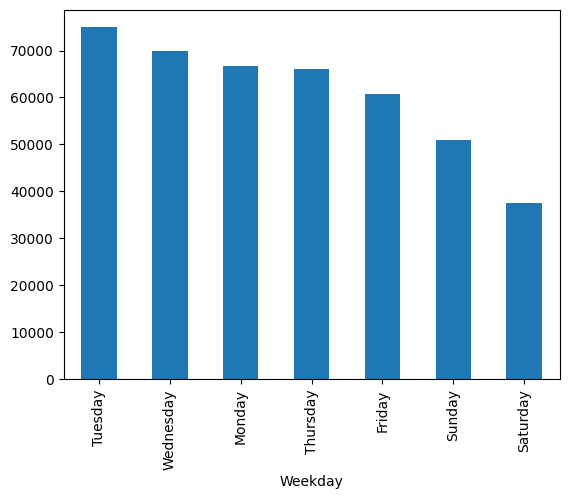

In [31]:
df['Weekday'].value_counts().plot(kind='bar')

# 👥 Member vs Casual Users

<Axes: >

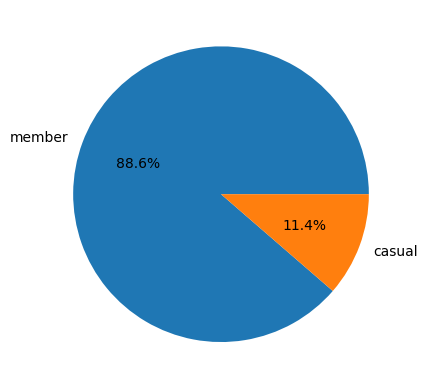

In [32]:
df['member_casual'].value_counts().plot(kind='pie', autopct='%1.1f%%')

# ⏱ Ride Duration Distribution

<Axes: ylabel='Frequency'>

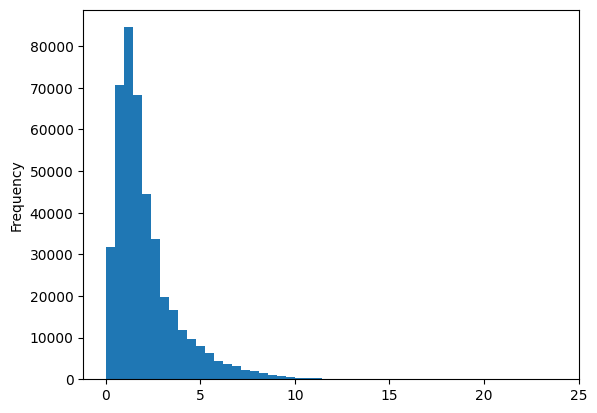

In [33]:
df['Distance Cover'].plot(kind='hist', bins=50)

# 📏 Distance vs Frequency

<Axes: xlabel='Distance Cover'>

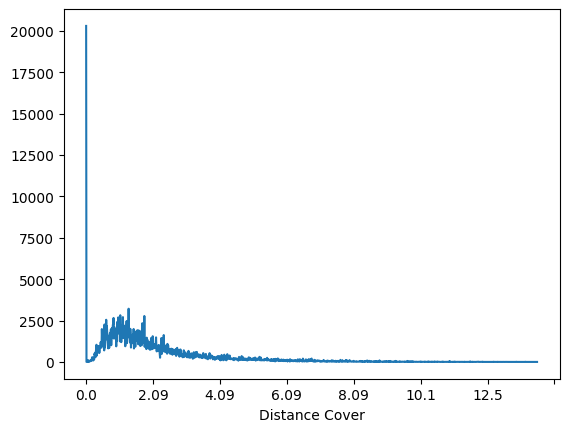

In [34]:
df['Distance Cover'].value_counts().sort_index().plot()

# Distance Band Count

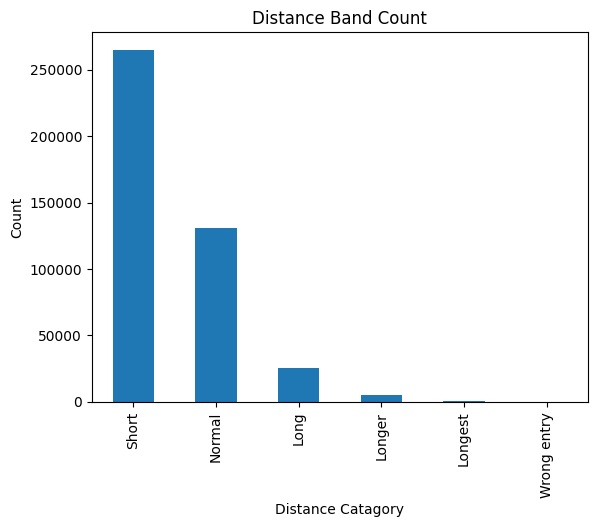

In [41]:
df['Distance Distribution'].value_counts().plot(kind='bar')
plt.title('Distance Band Count')
plt.xlabel('Distance Catagory')
plt.ylabel('Count')
plt.show()

# 🚲 Top Start Stations

<Axes: xlabel='start_station_name'>

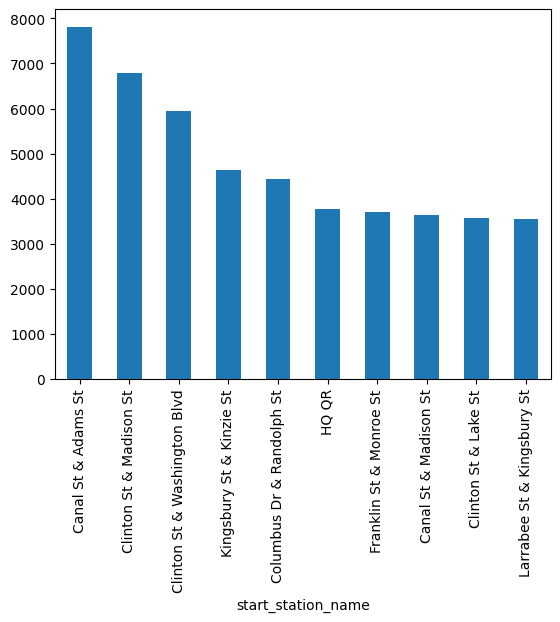

In [36]:
df['start_station_name'].value_counts().head(10).plot(kind='bar')

# 📍 Top End Stations

<Axes: xlabel='end_station_name'>

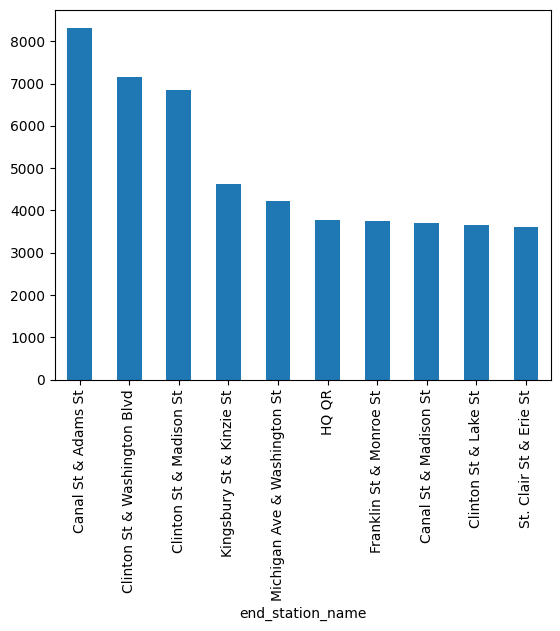

In [37]:
df['end_station_name'].value_counts().head(10).plot(kind='bar')

# 📊 Distance Cover by User Type

<Axes: xlabel='member_casual'>

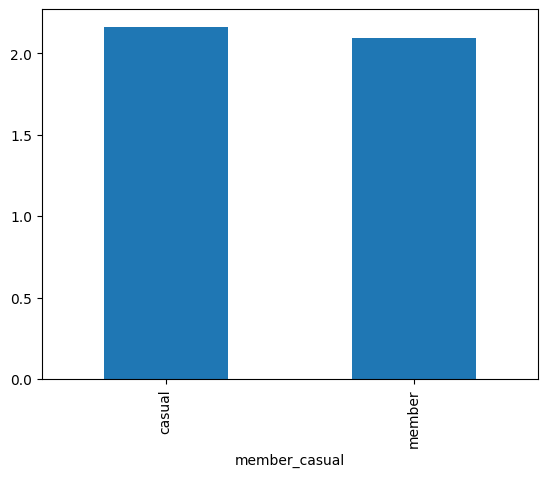

In [38]:
df.groupby('member_casual')['Distance Cover'].mean().plot(kind='bar')

# Busy Hours of the Day

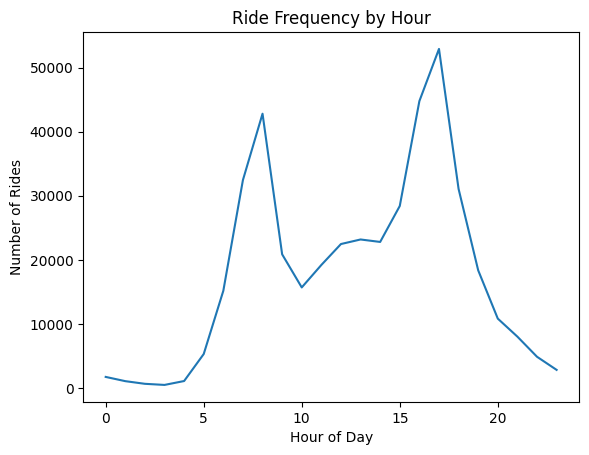

In [54]:
df['Time_start'] = pd.to_datetime(df['Time_start'])

df['hour'] = df['Time_start'].dt.hour

hour_frequency = df['hour'].value_counts().sort_index()

hour_frequency.plot(kind='line')

plt.title('Ride Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')

plt.show()